In [1]:
import numpy as np
import hmm
import emission_model
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../datasets/sp500_index.csv')

In [3]:

df["Date"] = pd.to_datetime(df["Date"])

In [4]:
L = df['S&P500'].shape[0]
init_train = 0
final_train = int((2 * L) // 3) - 1

init_test = int((2 * L) // 3) 
final_test = L-1

returns = np.log(df['S&P500'].shift(-1) /  df['S&P500'] )
data_obs = np.array(returns).reshape(1, -1)[:, init_train:final_train+1]

In [5]:
### Student's emission
err = []
HMM_list = []
for i in range(15):
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    #emission = emission_model.Discrete_Emission(2, data_obs, 2, B=None)
    student_params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0, 0.01), 6],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.01), 6],  # state 1
])
    emission = emission_model.Student_Emission(2, data_obs, student_params=student_params)
    HMM = hmm.Hmm(2, 2, emission, pi, A=None)
    err.append(HMM.Baum_Welch_algorithm(data_obs, N_max=35, eps=1e-8))
    HMM_list.append(HMM)
err = np.array(err)

state 0: f(nmin)=0.8344, f(nmax)=-0.0000
state 1: f(nmin)=42.0384, f(nmax)=-0.0001
state 0: f(nmin)=55.3065, f(nmax)=-0.0000
state 1: f(nmin)=37.2216, f(nmax)=-0.0000
state 0: f(nmin)=64.5768, f(nmax)=-0.0000
state 1: f(nmin)=37.6492, f(nmax)=-0.0000
state 0: f(nmin)=53.5876, f(nmax)=-0.0000
state 1: f(nmin)=38.9218, f(nmax)=-0.0000
state 0: f(nmin)=48.4649, f(nmax)=-0.0000
state 1: f(nmin)=39.2347, f(nmax)=-0.0000
state 0: f(nmin)=46.2184, f(nmax)=-0.0000
state 1: f(nmin)=39.2486, f(nmax)=-0.0000
state 0: f(nmin)=45.2090, f(nmax)=-0.0000
state 1: f(nmin)=39.1757, f(nmax)=-0.0000
state 0: f(nmin)=44.7100, f(nmax)=-0.0000
state 1: f(nmin)=39.0692, f(nmax)=-0.0000
state 0: f(nmin)=44.4348, f(nmax)=-0.0000
state 1: f(nmin)=38.9429, f(nmax)=-0.0000
state 0: f(nmin)=44.2218, f(nmax)=-0.0000
state 1: f(nmin)=38.8001, f(nmax)=-0.0000
state 0: f(nmin)=43.9084, f(nmax)=-0.0000
state 1: f(nmin)=38.6437, f(nmax)=-0.0000
state 0: f(nmin)=43.3528, f(nmax)=-0.0000
state 1: f(nmin)=38.4813, f(nmax)=-

ValueError: f(a) and f(b) must have different signs

In [ ]:
err = []
HMM_list = []
for i in range(15):
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    #emission = emission_model.Discrete_Emission(2, data_obs, 2, B=None)
    gauss_params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(-0.01, 0.01)],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(-0.01, 0.01)],  # state 1
])
    emission = emission_model.Gaussian_Emission(2, data_obs, gauss_params=gauss_params)
    HMM = hmm.Hmm(2, 2, emission, pi, A=None)
    err.append(HMM.Baum_Welch_algorithm(data_obs, N_max=35, eps=1e-8))
    HMM_list.append(HMM)
err = np.array(err)

KeyboardInterrupt: 

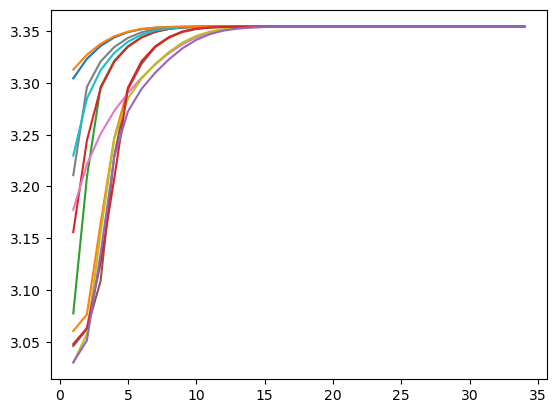

In [ ]:
import matplotlib.pyplot as plt

for i in range(15):
    
    plt.plot(range(1, np.array(err).shape[1]-1), np.array(err)[i, 2:])

In [ ]:
print(HMM_list[-1].emission.gauss_params)

if HMM_list[-1].emission.gauss_params[0, 0] <0:
    colors = ['red', 'green']

else:
    colors=colors = ['green', 'red']

[[-0.00143516  0.02104571]
 [ 0.0010474   0.00579982]]


In [ ]:
HMM.emission.gauss_params

array([[-0.00143516,  0.02104571],
       [ 0.0010474 ,  0.00579982]])

In [ ]:
HMM.Viterbi(data_obs)

In [ ]:
print(HMM.best_seqs.shape)

(1, 1678)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_regimes(dates,prices, hidden_states, n_states):
    
    
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    ax.plot(dates, prices, color='black', linewidth=2, zorder=2)
    
    # colora le regioni
    i = 0
    while i < len(hidden_states):
        state = int(hidden_states[i])
        j = i
        # trova fino a dove dura questo regime
        while j < len(hidden_states) and hidden_states[j] == state:
            j += 1
        ax.axvspan(dates[i], dates[min(j, len(dates)-1)], 
                   alpha=0.3, color=colors[state], zorder=1)
        i = j
    
    # legenda manuale
    from matplotlib.patches import Patch
    legend = [Patch(facecolor=colors[k], alpha=0.3, label=f'Regime {k}') 
              for k in range(n_states)]
    ax.legend(handles=legend, loc='upper left')
    
    ax.set_xlabel('time')
    ax.set_ylabel('return')
    plt.tight_layout()
    plt.show()

In [ ]:
df['S&P500'].shape
HMM.best_seqs[0, :].shape

(1678,)

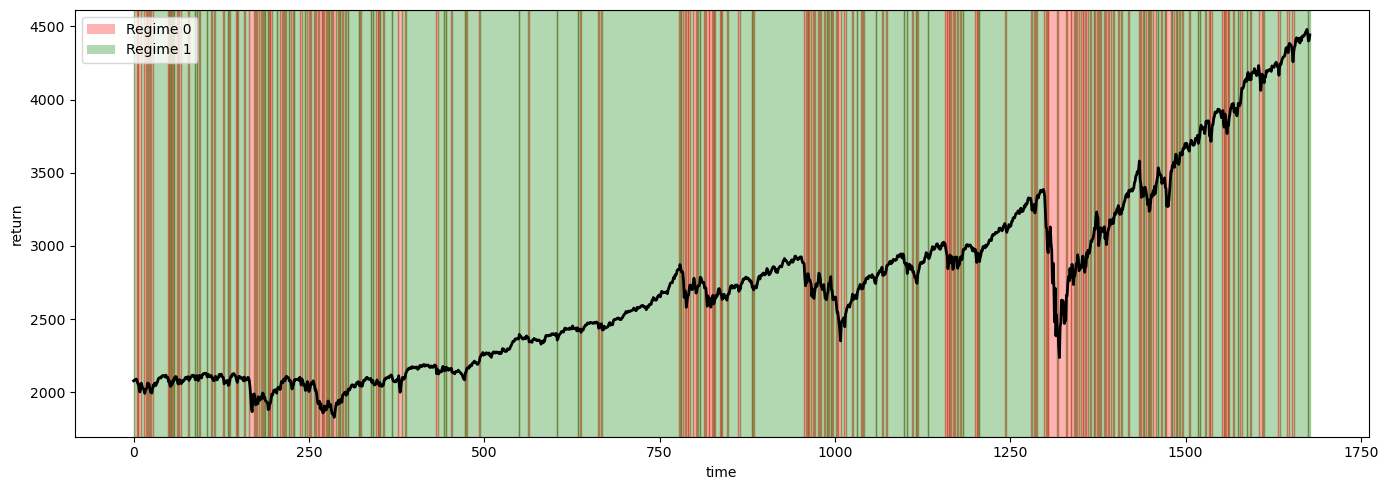

In [ ]:
dates = [i for i in range(final_train - init_train +1)]

plot_regimes(dates[:], np.array(df['S&P500'])[init_train:final_train+1], HMM.best_seqs[0, :] , n_states=2)

In [ ]:
data_obs_test=np.array(returns).reshape(1, -1)[:, init_test:final_test]
HMM.Viterbi(data_obs_test)

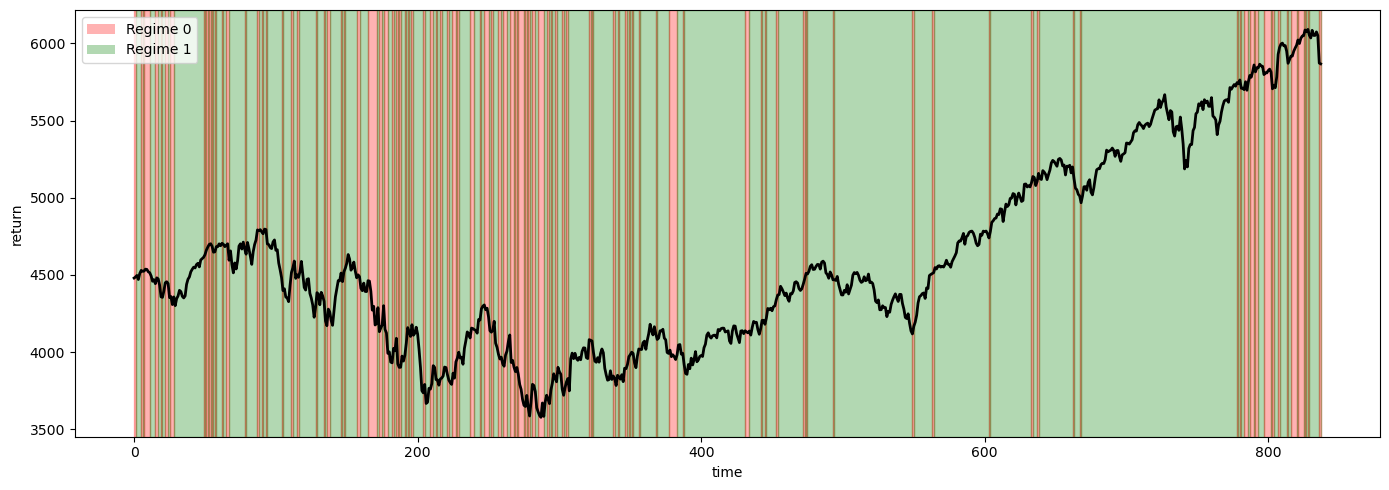

In [ ]:
dates = [i for i in range(final_test-init_test)]

plot_regimes(dates[:], np.array(df['S&P500'])[init_test:final_test], HMM.best_seqs[0, :] , n_states=2)

In [ ]:
test_likelihood = HMM.compute_likelihood(data_obs_test)

In [ ]:
test_likelihood

array([3.5076636])

In [ ]:
### Student's emission
err = []
HMM_list = []
for i in range(15):
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    #emission = emission_model.Discrete_Emission(2, data_obs, 2, B=None)
    student_params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(-0.01, 0.01), 6],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(-0.01, 0.01), 6],  # state 1
])
    emission = emission_model.Student_Emission(2, data_obs, student_params=student_params)
    HMM = hmm.Hmm(2, 2, emission, pi, A=None)
    err.append(HMM.Baum_Welch_algorithm(data_obs, N_max=35, eps=1e-8))
    HMM_list.append(HMM)
err = np.array(err)

ValueError: f(a) and f(b) must have different signs